In [1]:
from opensearchpy import OpenSearch

host = 'siemmaster.csatn.in'
port = 9200
auth = ('admin', 'Root1234#$') # For testing only. Don't store credentials in code.
ca_certs_path = 'C:/Users/rjha1/OneDrive/Desktop/Python/newca.pem'    # Path for key document(newca.pem)



client = OpenSearch(
    hosts = [{'host': host, 'port': port}],
    http_compress = True,  # enables gzip compression for request bodies
    http_auth = auth,
    use_ssl = True,
    verify_certs = True,
    ssl_assert_hostname = False,
    ssl_show_warn = False,
    ca_certs = ca_certs_path
)

In [2]:
client.info()

{'name': 'siemmaster',
 'cluster_name': 'bsiem',
 'cluster_uuid': 'MjUcKBmpSXK6UjSpf-puNQ',
 'version': {'number': '7.10.2',
  'build_flavor': 'oss',
  'build_type': 'deb',
  'build_hash': '747e1cc71def077253878a59143c1f785afa92b9',
  'build_date': '2021-01-13T00:42:12.435326Z',
  'build_snapshot': False,
  'lucene_version': '8.7.0',
  'minimum_wire_compatibility_version': '6.8.0',
  'minimum_index_compatibility_version': '6.0.0-beta1'},
 'tagline': 'You Know, for Search'}

In [3]:
from datetime import datetime

SIZE = 10000
start_date = "2023-03-10T00:00:00Z"
end_date = "2023-03-10T23:59:59Z"

query={
  "_source": ["@timestamp","srcip","dstip","srcport","dstport","geosrc.country_code2","geosrc.latitude","geosrc.longitude","geodest.country_code2","geodest.latitude","geodest.longitude","msg","proto","rule"],
  "size": SIZE,
  "min_score": 1,  
  "query": {
    "bool": {
      "must": [
        {
          "range": {
            "@timestamp": {
              "gte": start_date,
              "lte": end_date
            }
          }
        }
      ]
    }
  }
}


In [4]:
response = client.search(
    body = query,
    index = "sonic*"   
    )


c:\Users\rjha1\AppData\Local\Programs\Python\Python311\Lib\site-packages\opensearchpy\connection\base.py:174: OpenSearchWarning: this request accesses system indices: [.kibana_-152937574_admintenant_1, .kibana_-653081151_elastalert_1, .kibana_1, .kibana_113714_sdc_1, .kibana_1366709042_roadmin_1, .kibana_1932363519_reportuser_1, .kibana_279926056_prematest_1, .kibana_63497408_bsiem_1, .kibana_92668751_admin_1, .opendistro-anomaly-results-history-2021.08.09-1], but in a future major version, direct access to system indices will be prevented by default
  warnings.warn(message, category=OpenSearchWarning)


In [5]:
print(response)

{'took': 366, 'timed_out': False, '_shards': {'total': 70, 'successful': 70, 'skipped': 0, 'failed': 0}, 'hits': {'total': {'value': 10000, 'relation': 'gte'}, 'max_score': 1.0, 'hits': [{'_index': 'sonicwall-2023-03-10', '_type': '_doc', '_id': '5OagyYYBf-rpwABkyYc6', '_score': 1.0, '_source': {'msg': 'Connection Opened', 'srcip': '139.59.138.127', '@timestamp': '2023-03-10T08:47:02.000Z', 'dstport': '37954', 'geodest': {'latitude': 20.0, 'country_code2': 'IN', 'longitude': 77.0}, 'geosrc': {'latitude': 50.1155, 'country_code2': 'DE', 'longitude': 8.6842}, 'proto': 'tcp/37954', 'srcport': '42187', 'dstip': '14.139.180.46'}}, {'_index': 'sonicwall-2023-03-10', '_type': '_doc', '_id': '5eagyYYBf-rpwABkyYc6', '_score': 1.0, '_source': {'msg': 'Connection Closed', 'srcip': '139.59.138.127', '@timestamp': '2023-03-10T08:47:02.000Z', 'dstport': '37954', 'geodest': {'latitude': 20.0, 'country_code2': 'IN', 'longitude': 77.0}, 'geosrc': {'latitude': 50.1155, 'country_code2': 'DE', 'longitude'

In [6]:
elastic_docs = response["hits"]["hits"]
# print number of documents returned
print ("documents returned:",  len(response["hits"]["hits"]))

documents returned: 10000


In [7]:
from pandas import json_normalize
import pandas as pd
df = json_normalize(response['hits']['hits'])
df.head(10000)


,_index,_type,_id,_score,_source.msg,_source.srcip,_source.@timestamp,_source.dstport,_source.geodest.latitude,_source.geodest.country_code2,_source.geodest.longitude,_source.geosrc.latitude,_source.geosrc.country_code2,_source.geosrc.longitude,_source.proto,_source.srcport,_source.dstip,_source.rule
0,sonicwall-2023-03-10,_doc,5OagyYYBf-rpwABkyYc6,1.0,Connection Opened,139.59.138.127,2023-03-10T08:47:02.000Z,37954,20.0000,IN,77.000,50.1155,DE,8.6842,tcp/37954,42187,14.139.180.46,NaN
1,sonicwall-2023-03-10,_doc,5eagyYYBf-rpwABkyYc6,1.0,Connection Closed,139.59.138.127,2023-03-10T08:47:02.000Z,37954,20.0000,IN,77.000,50.1155,DE,8.6842,tcp/37954,42187,14.139.180.46,NaN
2,sonicwall-2023-03-10,_doc,6eagyYYBf-rpwABkyYc6,1.0,Connection Opened,47.29.172.138,2023-03-10T08:47:02.000Z,443,NaN,NaN,NaN,24.8273,IN,92.7979,tcp/https,2404,10.184.61.15,NaN
3,sonicwall-2023-03-10,_doc,7eagyYYBf-rpwABkyYe-,1.0,Connection Closed,62.77.157.49,2023-03-10T08:47:02.000Z,8069,NaN,NaN,NaN,56.0000,LT,24.0000,tcp/8069,52030,10.184.49.222,92 (WAN->LAN)
4,sonicwall-2023-03-10,_doc,7uagyYYBf-rpwABkyYe-,1.0,Connection Closed,47.29.173.33,2023-03-10T08:47:02.000Z,443,NaN,NaN,NaN,26.1761,IN,91.7629,tcp/https,45966,10.184.61.15,132 (WAN->LAN)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,sonicwall-2023-03-10,_doc,aeiwyYYBf-rpwABk7R5q,1.0,Connection Closed,10.184.46.197,2023-03-10T09:04:40.000Z,8081,1.3667,SG,103.800,NaN,NaN,NaN,tcp/8081,58228,129.226.106.34,NaN
9996,sonicwall-2023-03-10,_doc,a-iwyYYBf-rpwABk7R5q,1.0,Connection Opened,10.184.36.166,2023-03-10T09:04:40.000Z,443,20.0000,IN,77.000,NaN,NaN,NaN,tcp/https,34704,196.1.113.206,NaN
9997,sonicwall-2023-03-10,_doc,cuiwyYYBf-rpwABk7R63,1.0,Connection Opened,10.184.36.176,2023-03-10T09:04:40.000Z,443,37.7510,US,-97.822,NaN,NaN,NaN,tcp/https,54766,172.217.31.206,NaN
9998,sonicwall-2023-03-10,_doc,deiwyYYBf-rpwABk7h4L,1.0,Connection Opened,79.110.62.234,2023-03-10T09:04:40.000Z,80,20.0000,IN,77.000,51.2993,DE,9.4910,tcp/http,47689,14.139.180.52,NaN


Data1.csv export

In [8]:
df.to_csv("data1.csv", index=True)

In [9]:
#For the similar ip_address that start with 10. that document has been deleted

df = df[~((df['_source.srcip'].str.startswith("10.")) & (df['_source.dstip'].str.startswith("10.")))]
print(df)

                    _index _type                   _id  _score  \
0     sonicwall-2023-03-10  _doc  5OagyYYBf-rpwABkyYc6     1.0   
1     sonicwall-2023-03-10  _doc  5eagyYYBf-rpwABkyYc6     1.0   
2     sonicwall-2023-03-10  _doc  6eagyYYBf-rpwABkyYc6     1.0   
3     sonicwall-2023-03-10  _doc  7eagyYYBf-rpwABkyYe-     1.0   
4     sonicwall-2023-03-10  _doc  7uagyYYBf-rpwABkyYe-     1.0   
...                    ...   ...                   ...     ...   
9995  sonicwall-2023-03-10  _doc  aeiwyYYBf-rpwABk7R5q     1.0   
9996  sonicwall-2023-03-10  _doc  a-iwyYYBf-rpwABk7R5q     1.0   
9997  sonicwall-2023-03-10  _doc  cuiwyYYBf-rpwABk7R63     1.0   
9998  sonicwall-2023-03-10  _doc  deiwyYYBf-rpwABk7h4L     1.0   
9999  sonicwall-2023-03-10  _doc  duiwyYYBf-rpwABk7h4L     1.0   

            _source.msg   _source.srcip        _source.@timestamp  \
0     Connection Opened  139.59.138.127  2023-03-10T08:47:02.000Z   
1     Connection Closed  139.59.138.127  2023-03-10T08:47:02.000Z   


In [10]:
# assign the geolocation NaN data with given lat and log form both src and dst 

import pandas as pd

# Create a boolean mask to identify rows with IP address 10.184 in either the 'src' or 'dest' columns
mask = (df['_source.srcip'].str.startswith('10.184')) | (df['_source.dstip'].str.startswith('10.184'))

# Replace NaN values in the 'lat' and 'lon' columns of those rows with the corresponding values from the 'lat_lon' column
df.loc[mask, '_source.geosrc.latitude'] = df.loc[mask, '_source.geosrc.latitude'].fillna(13.0878)
df.loc[mask, '_source.geosrc.longitude'] = df.loc[mask, '_source.geosrc.longitude'].fillna(80.2785)
df.loc[mask, '_source.geodest.latitude'] = df.loc[mask, '_source.geodest.latitude'].fillna(13.0878)
df.loc[mask, '_source.geodest.longitude'] = df.loc[mask, '_source.geodest.longitude'].fillna(80.2785)

# Replace NaN values in the 'lat' and 'lon' columns of those rows with the corresponding values from the 'lat_lon' column
df.loc[mask, '_source.geosrc.country_code2'] = df.loc[mask, '_source.geosrc.country_code2'].fillna("IN")
df.loc[mask, '_source.geodest.country_code2'] = df.loc[mask, '_source.geodest.country_code2'].fillna("IN")

# Save the updated DataFrame to a new file
df.to_csv("data2.csv", index=True)

Data2.csv export

In [11]:
# Load your data into a pandas DataFrame

df = pd.read_csv("data2.csv")

In [12]:
df.head(10000)

,Unnamed: 0,_index,_type,_id,_score,_source.msg,_source.srcip,_source.@timestamp,_source.dstport,_source.geodest.latitude,_source.geodest.country_code2,_source.geodest.longitude,_source.geosrc.latitude,_source.geosrc.country_code2,_source.geosrc.longitude,_source.proto,_source.srcport,_source.dstip,_source.rule
0,0,sonicwall-2023-03-10,_doc,5OagyYYBf-rpwABkyYc6,1.0,Connection Opened,139.59.138.127,2023-03-10T08:47:02.000Z,37954,20.0000,IN,77.0000,50.1155,DE,8.6842,tcp/37954,42187,14.139.180.46,NaN
1,1,sonicwall-2023-03-10,_doc,5eagyYYBf-rpwABkyYc6,1.0,Connection Closed,139.59.138.127,2023-03-10T08:47:02.000Z,37954,20.0000,IN,77.0000,50.1155,DE,8.6842,tcp/37954,42187,14.139.180.46,NaN
2,2,sonicwall-2023-03-10,_doc,6eagyYYBf-rpwABkyYc6,1.0,Connection Opened,47.29.172.138,2023-03-10T08:47:02.000Z,443,13.0878,IN,80.2785,24.8273,IN,92.7979,tcp/https,2404,10.184.61.15,NaN
3,3,sonicwall-2023-03-10,_doc,7eagyYYBf-rpwABkyYe-,1.0,Connection Closed,62.77.157.49,2023-03-10T08:47:02.000Z,8069,13.0878,IN,80.2785,56.0000,LT,24.0000,tcp/8069,52030,10.184.49.222,92 (WAN->LAN)
4,4,sonicwall-2023-03-10,_doc,7uagyYYBf-rpwABkyYe-,1.0,Connection Closed,47.29.173.33,2023-03-10T08:47:02.000Z,443,13.0878,IN,80.2785,26.1761,IN,91.7629,tcp/https,45966,10.184.61.15,132 (WAN->LAN)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9674,9995,sonicwall-2023-03-10,_doc,aeiwyYYBf-rpwABk7R5q,1.0,Connection Closed,10.184.46.197,2023-03-10T09:04:40.000Z,8081,1.3667,SG,103.8000,13.0878,IN,80.2785,tcp/8081,58228,129.226.106.34,NaN
9675,9996,sonicwall-2023-03-10,_doc,a-iwyYYBf-rpwABk7R5q,1.0,Connection Opened,10.184.36.166,2023-03-10T09:04:40.000Z,443,20.0000,IN,77.0000,13.0878,IN,80.2785,tcp/https,34704,196.1.113.206,NaN
9676,9997,sonicwall-2023-03-10,_doc,cuiwyYYBf-rpwABk7R63,1.0,Connection Opened,10.184.36.176,2023-03-10T09:04:40.000Z,443,37.7510,US,-97.8220,13.0878,IN,80.2785,tcp/https,54766,172.217.31.206,NaN
9677,9998,sonicwall-2023-03-10,_doc,deiwyYYBf-rpwABk7h4L,1.0,Connection Opened,79.110.62.234,2023-03-10T09:04:40.000Z,80,20.0000,IN,77.0000,51.2993,DE,9.4910,tcp/http,47689,14.139.180.52,NaN


In [13]:
print(df[df['_source.geosrc.latitude'].isnull()])

      Unnamed: 0                _index _type                   _id  _score  \
151          154  sonicwall-2023-03-10  _doc  LuagyYYBf-rpwABk2olZ     1.0   
701          719  sonicwall-2023-03-10  _doc  AOahyYYBf-rpwABkHI7a     1.0   
739          757  sonicwall-2023-03-10  _doc  S-ahyYYBf-rpwABkII4H     1.0   
1364        1390  sonicwall-2023-03-10  _doc  6OajyYYBf-rpwABki8cS     1.0   
1367        1393  sonicwall-2023-03-10  _doc  6-ajyYYBf-rpwABki8e7     1.0   
1512        1538  sonicwall-2023-03-10  _doc  6-agyYYBf-rpwABksYXL     1.0   
2143        2176  sonicwall-2023-03-10  _doc  XeaiyYYBf-rpwABklLF9     1.0   
2253        2333  sonicwall-2023-03-10  _doc  8OaiyYYBf-rpwABkkrCt     1.0   
2618        2758  sonicwall-2023-03-10  _doc  TOalyYYBf-rpwABkRO-J     1.0   
2619        2759  sonicwall-2023-03-10  _doc  TealyYYBf-rpwABkRO-J     1.0   
3991        4150  sonicwall-2023-03-10  _doc  POenyYYBf-rpwABkSymD     1.0   
4095        4255  sonicwall-2023-03-10  _doc  jeenyYYBf-rpwABkPC

In [14]:
print(df[df['_source.geodest.latitude'].isnull()])

Empty DataFrame
Columns: [Unnamed: 0, _index, _type, _id, _score, _source.msg, _source.srcip, _source.@timestamp, _source.dstport, _source.geodest.latitude, _source.geodest.country_code2, _source.geodest.longitude, _source.geosrc.latitude, _source.geosrc.country_code2, _source.geosrc.longitude, _source.proto, _source.srcport, _source.dstip, _source.rule]
Index: []


In [15]:
print(df[df['_source.geosrc.country_code2'].isnull()])

      Unnamed: 0                _index _type                   _id  _score  \
151          154  sonicwall-2023-03-10  _doc  LuagyYYBf-rpwABk2olZ     1.0   
701          719  sonicwall-2023-03-10  _doc  AOahyYYBf-rpwABkHI7a     1.0   
739          757  sonicwall-2023-03-10  _doc  S-ahyYYBf-rpwABkII4H     1.0   
1364        1390  sonicwall-2023-03-10  _doc  6OajyYYBf-rpwABki8cS     1.0   
1367        1393  sonicwall-2023-03-10  _doc  6-ajyYYBf-rpwABki8e7     1.0   
1512        1538  sonicwall-2023-03-10  _doc  6-agyYYBf-rpwABksYXL     1.0   
2143        2176  sonicwall-2023-03-10  _doc  XeaiyYYBf-rpwABklLF9     1.0   
2253        2333  sonicwall-2023-03-10  _doc  8OaiyYYBf-rpwABkkrCt     1.0   
2618        2758  sonicwall-2023-03-10  _doc  TOalyYYBf-rpwABkRO-J     1.0   
2619        2759  sonicwall-2023-03-10  _doc  TealyYYBf-rpwABkRO-J     1.0   
3991        4150  sonicwall-2023-03-10  _doc  POenyYYBf-rpwABkSymD     1.0   
4095        4255  sonicwall-2023-03-10  _doc  jeenyYYBf-rpwABkPC

In [16]:
print(df[df['_source.geodest.country_code2'].isnull()])

Empty DataFrame
Columns: [Unnamed: 0, _index, _type, _id, _score, _source.msg, _source.srcip, _source.@timestamp, _source.dstport, _source.geodest.latitude, _source.geodest.country_code2, _source.geodest.longitude, _source.geosrc.latitude, _source.geosrc.country_code2, _source.geosrc.longitude, _source.proto, _source.srcport, _source.dstip, _source.rule]
Index: []


In [17]:
import ipinfo

def get_location(ip):
    try:
        handler = ipinfo.getHandler(token="your_token_here")
        details = handler.getDetails(ip)
        return details.latitude, details.longitude, details.country
    except Exception as e:
        print('Exception in fetching IP address:',e)
        return None, None, None

for index, row in df.iterrows():
    if pd.isna(row['_source.geosrc.latitude']) or pd.isna(row['_source.geosrc.longitude']):
        latitude, longitude, country = get_location(row['_source.srcip'])
        if pd.isna(row['_source.geosrc.latitude']):
            df.at[index, '_source.geosrc.latitude'] = latitude
        if pd.isna(row['_source.geosrc.longitude']):
            df.at[index, '_source.geosrc.longitude'] = longitude
        if pd.isna(row['_source.geosrc.country_code2']):
            df.at[index, '_source.geosrc.country_code2'] = country
    if pd.isna(row['_source.geodest.latitude']) or pd.isna(row['_source.geodest.longitude']):
        latitude, longitude, country = get_location(row['_source.dstip'])
        if pd.isna(row['_source.geodest.latitude']):
            df.at[index, '_source.geodest.latitude'] = latitude
        if pd.isna(row['_source.geodest.longitude']):
            df.at[index, '_source.geodest.longitude'] = longitude
        if pd.isna(row['_source.geodest.country_code2']):
            df.at[index, '_source.geodest.country_code2'] = country
            
df.to_csv("change.csv", index=False)


Change.csv export

In [18]:
print(df[df['_source.geosrc.latitude'].isnull()])

Empty DataFrame
Columns: [Unnamed: 0, _index, _type, _id, _score, _source.msg, _source.srcip, _source.@timestamp, _source.dstport, _source.geodest.latitude, _source.geodest.country_code2, _source.geodest.longitude, _source.geosrc.latitude, _source.geosrc.country_code2, _source.geosrc.longitude, _source.proto, _source.srcport, _source.dstip, _source.rule]
Index: []


In [19]:
print(df[df['_source.geosrc.country_code2'].isnull()])

Empty DataFrame
Columns: [Unnamed: 0, _index, _type, _id, _score, _source.msg, _source.srcip, _source.@timestamp, _source.dstport, _source.geodest.latitude, _source.geodest.country_code2, _source.geodest.longitude, _source.geosrc.latitude, _source.geosrc.country_code2, _source.geosrc.longitude, _source.proto, _source.srcport, _source.dstip, _source.rule]
Index: []


In [20]:
# in this cell i have to write the row where both scr_ip and dest_ip are missing

In [21]:
data = pd.read_csv('change.csv')
print(data.head())

   Unnamed: 0                _index _type                   _id  _score  \
0           0  sonicwall-2023-03-10  _doc  5OagyYYBf-rpwABkyYc6     1.0   
1           1  sonicwall-2023-03-10  _doc  5eagyYYBf-rpwABkyYc6     1.0   
2           2  sonicwall-2023-03-10  _doc  6eagyYYBf-rpwABkyYc6     1.0   
3           3  sonicwall-2023-03-10  _doc  7eagyYYBf-rpwABkyYe-     1.0   
4           4  sonicwall-2023-03-10  _doc  7uagyYYBf-rpwABkyYe-     1.0   

         _source.msg   _source.srcip        _source.@timestamp  \
0  Connection Opened  139.59.138.127  2023-03-10T08:47:02.000Z   
1  Connection Closed  139.59.138.127  2023-03-10T08:47:02.000Z   
2  Connection Opened   47.29.172.138  2023-03-10T08:47:02.000Z   
3  Connection Closed    62.77.157.49  2023-03-10T08:47:02.000Z   
4  Connection Closed    47.29.173.33  2023-03-10T08:47:02.000Z   

   _source.dstport  _source.geodest.latitude _source.geodest.country_code2  \
0            37954                   20.0000                            IN

In [22]:
#virtualize the hit_count as heatmap

import pandas as pd
import folium
from folium.plugins import HeatMap

df = pd.read_csv('change.csv')
hit_counts = df.groupby(['_source.srcip', '_source.dstip', '_source.proto']).size().reset_index(name='counts')

ip_coords = pd.DataFrame(columns=['ip', 'lat', 'lon'])
unique_ips = pd.concat([df['_source.srcip'], df['_source.dstip']]).unique()

for ip in unique_ips:
    ip_df = df.loc[(df['_source.srcip'] == ip) | (df['_source.dstip'] == ip)]
    lat = ip_df.iloc[0]['_source.geosrc.latitude'] if ip_df.iloc[0]['_source.srcip'] == ip else ip_df.iloc[0]['_source.geodest.latitude']
    lon = ip_df.iloc[0]['_source.geosrc.longitude'] if ip_df.iloc[0]['_source.srcip'] == ip else ip_df.iloc[0]['_source.geodest.longitude']
    ip_coords = pd.concat([ip_coords, pd.DataFrame({'ip': [ip], 'lat': [lat], 'lon': [lon]})], ignore_index=True)

total_hits = hit_counts['counts'].sum()
print(f"Total number of hits: {total_hits}")

# Create a new DataFrame to hold the hit count data
table_data = pd.DataFrame(columns=['Source IP', 'Destination IP', 'Protocol', 'Hit Count'])

# Initialize heat_data as an empty list
heat_data = []

for index, row in hit_counts.iterrows():
    src_ip = row['_source.srcip']
    dst_ip = row['_source.dstip']
    proto = row['_source.proto']
    count = row['counts']
    src_lat = ip_coords[ip_coords['ip'] == src_ip]['lat'].values[0]
    src_lon = ip_coords[ip_coords['ip'] == src_ip]['lon'].values[0]
    dst_lat = ip_coords[ip_coords['ip'] == dst_ip]['lat'].values[0]
    dst_lon = ip_coords[ip_coords['ip'] == dst_ip]['lon'].values[0]
    heat_data.append([src_lat, src_lon, count])
    heat_data.append([dst_lat, dst_lon, count])
    
    # Add the hit count data to the table DataFrame
    table_data = pd.concat([table_data, pd.DataFrame({
        'Source IP': [src_ip],
        'Destination IP': [dst_ip],
        'Protocol': [proto],
        'Hit Count': [count]
    })], ignore_index=True)

# Output the hit count data as an HTML table
table_html = table_data.to_html(index=True)

# Output the heat map
map = folium.Map(location=[ip_coords['lat'].mean(), ip_coords['lon'].mean()], zoom_start=2)
HeatMap(heat_data).add_to(map)
map.save('heatmap.html')

# Output the hit count data table as a separate HTML file
with open('table.html', 'w') as file:
    file.write(table_html)


Total number of hits: 9679


The above code of heatmap is execute as heatmap.html file

In [23]:
#virtualize on map as dotplot

import pandas as pd
import folium

df = pd.read_csv('change.csv')
hit_counts = df.groupby(['_source.srcip', '_source.dstip', '_source.proto']).size().reset_index(name='counts')

ip_coords = pd.DataFrame(columns=['ip', 'lat', 'lon'])
unique_ips = pd.concat([df['_source.srcip'], df['_source.dstip']]).unique()

for ip in unique_ips:
    ip_df = df.loc[(df['_source.srcip'] == ip) | (df['_source.dstip'] == ip)]
    lat = ip_df.iloc[0]['_source.geosrc.latitude'] if ip_df.iloc[0]['_source.srcip'] == ip else ip_df.iloc[0]['_source.geodest.latitude']
    lon = ip_df.iloc[0]['_source.geosrc.longitude'] if ip_df.iloc[0]['_source.srcip'] == ip else ip_df.iloc[0]['_source.geodest.longitude']
    ip_coords = pd.concat([ip_coords, pd.DataFrame({'ip': [ip], 'lat': [lat], 'lon': [lon]})], ignore_index=True)

total_hits = hit_counts['counts'].sum()
print(f"Total number of hits: {total_hits}")

# Create a new DataFrame to hold the hit count data
table_data = pd.DataFrame(columns=['Source IP', 'Destination IP', 'Protocol', 'Hit Count'])

# Create a list to hold the circle data
circle_data = []

for index, row in hit_counts.iterrows():
    src_ip = row['_source.srcip']
    dst_ip = row['_source.dstip']
    proto = row['_source.proto']
    count = row['counts']
    src_lat = ip_coords[ip_coords['ip'] == src_ip]['lat'].values[0]
    src_lon = ip_coords[ip_coords['ip'] == src_ip]['lon'].values[0]
    dst_lat = ip_coords[ip_coords['ip'] == dst_ip]['lat'].values[0]
    dst_lon = ip_coords[ip_coords['ip'] == dst_ip]['lon'].values[0]

    # Add the hit count data to the table DataFrame
    table_data = pd.concat([table_data, pd.DataFrame({
        'Source IP': [src_ip],
        'Destination IP': [dst_ip],
        'Protocol': [proto],
        'Hit Count': [count]
    })], ignore_index=True)

    # Add the circle data
    circle_data.append({
        'location': [src_lat, src_lon],
        'radius': count,
        'color': 'red',
        'tooltip': f'Source IP: {src_ip}<br>Destination IP: {dst_ip}<br>Protocol: {proto}<br>Hit Count: {count}'
    })
    circle_data.append({
        'location': [dst_lat, dst_lon],
        'radius': count,
        'color': 'blue',
        'tooltip': f'Source IP: {src_ip}<br>Destination IP: {dst_ip}<br>Protocol: {proto}<br>Hit Count: {count}'
    })

# Output the dot plot
map = folium.Map(location=[ip_coords['lat'].mean(), ip_coords['lon'].mean()], zoom_start=2)
for circle in circle_data:
    folium.Circle(location=circle['location'], radius=circle['radius'], color=circle['color'], tooltip=circle['tooltip']).add_to(map)
map.save('dot.html')


# Output the hit count data table as a separate HTML file
with open('table.html', 'w') as file:
    file.write(table_html)


Total number of hits: 9679


The above code of folium is execute as dot.html file

In [24]:
#finding distance

import math
import pandas as pd
import builtins

# Load the CSV file into a Pandas DataFrame
df = pd.read_csv('change.csv')

# Define the Haversine formula function
def haversine(lat1, lon1, lat2, lon2):
    # Convert latitude and longitude to radians
    lon1_rad, lat1_rad, lon2_rad, lat2_rad = builtins.map(math.radians, [lon1, lat1, lon2, lat2])
    
    # Calculate the differences between latitudes and longitudes
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    # Apply the Haversine formula
    a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
    r = 6371 # Radius of the earth in kilometers
    
    # Calculate the distance
    distance = r * c
    
    return distance

# Calculate the distance between the geographic locations of the source and destination IPs for each row
distances = []
for index, row in df.iterrows():
    # Get the latitude and longitude of the source and destination IPs
    src_lat = row['_source.geosrc.latitude']
    src_lon = row['_source.geosrc.longitude']
    dst_lat = row['_source.geodest.latitude']
    dst_lon = row['_source.geodest.longitude']
    
    # Calculate the distance using the Haversine formula
    distance = haversine(src_lat, src_lon, dst_lat, dst_lon)
    
    # Add the distance to the list of distances
    distances.append(distance)

# Add the distances as a new column in the DataFrame
df['distance'] = distances

df.to_csv("change1.csv", index=False)

# Print the DataFrame to check the results
print(df)


      Unnamed: 0                _index _type                   _id  _score  \
0              0  sonicwall-2023-03-10  _doc  5OagyYYBf-rpwABkyYc6     1.0   
1              1  sonicwall-2023-03-10  _doc  5eagyYYBf-rpwABkyYc6     1.0   
2              2  sonicwall-2023-03-10  _doc  6eagyYYBf-rpwABkyYc6     1.0   
3              3  sonicwall-2023-03-10  _doc  7eagyYYBf-rpwABkyYe-     1.0   
4              4  sonicwall-2023-03-10  _doc  7uagyYYBf-rpwABkyYe-     1.0   
...          ...                   ...   ...                   ...     ...   
9674        9995  sonicwall-2023-03-10  _doc  aeiwyYYBf-rpwABk7R5q     1.0   
9675        9996  sonicwall-2023-03-10  _doc  a-iwyYYBf-rpwABk7R5q     1.0   
9676        9997  sonicwall-2023-03-10  _doc  cuiwyYYBf-rpwABk7R63     1.0   
9677        9998  sonicwall-2023-03-10  _doc  deiwyYYBf-rpwABk7h4L     1.0   
9678        9999  sonicwall-2023-03-10  _doc  duiwyYYBf-rpwABk7h4L     1.0   

            _source.msg   _source.srcip        _source.@timesta

The above code Finding distance using Haversine Formula and export the file as change1.csv file

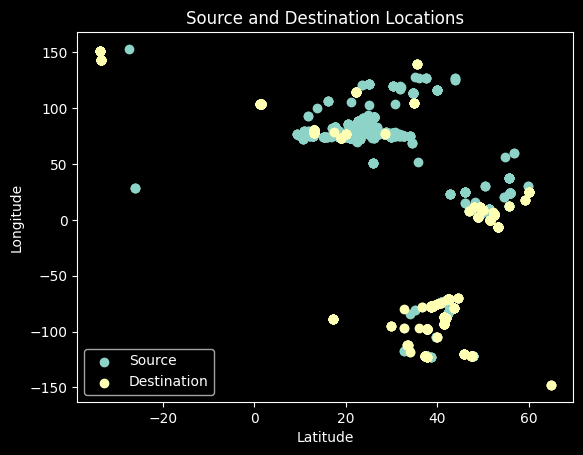

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file into a Pandas dataframe
data = pd.read_csv('change1.csv')

# Create a scatter plot of source and destination latitude and longitude
plt.scatter(data['_source.geosrc.latitude'], data['_source.geosrc.longitude'], label='Source')
plt.scatter(data['_source.geodest.latitude'], data['_source.geodest.longitude'], label='Destination')
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.title('Source and Destination Locations')
plt.legend()
plt.show()


In [27]:
import plotly.graph_objs as go
import pandas as pd

# Load the CSV file into a Pandas dataframe
data = pd.read_csv('change1.csv')

# Create a scatter plot of source and destination latitude and longitude
fig = go.Figure()
fig.add_trace(go.Scatter(x=data['_source.geosrc.latitude'], y=data['_source.geosrc.longitude'], mode='markers', name='Source'))
fig.add_trace(go.Scatter(x=data['_source.geodest.latitude'], y=data['_source.geodest.longitude'], mode='markers', name='Destination'))

fig.update_layout(title='Source and Destination Locations',
                  xaxis_title='Latitude',
                  yaxis_title='Longitude',
                  legend_title='Locations',
                  width=800, height=600)

fig.show()


In [28]:
import pandas as pd
import plotly.express as px

# Load the CSV file into a Pandas dataframe
data = pd.read_csv('change1.csv')

# Create a scatter plot of source and destination locations
fig = px.scatter_mapbox(data, lat="_source.geosrc.latitude", lon="_source.geosrc.longitude",
                        hover_name="_source.srcip", hover_data=["_source.geodest.latitude", "_source.geodest.longitude", "_source.dstip"],
                        zoom=8, height=600)

fig.update_layout(mapbox_style="open-street-map")
fig.show()


In [29]:
#1. find the anomalies using distance and geographic location islolation model

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score

# Load data from CSV file
df = pd.read_csv('change1.csv')

# Convert timestamp to datetime object
df['timestamp'] = pd.to_datetime(df['_source.@timestamp'])

# Group data by source and destination geographic coordinates, and calculate hit counts and average distance
X = df.groupby(['_source.geosrc.latitude', '_source.geosrc.longitude', '_source.geodest.latitude', '_source.geodest.longitude']).agg(hit_counts=('distance', 'count'), distance=('distance', 'mean')).reset_index()

# Drop unnecessary columns
#X = X.drop(columns=['_source.@timestamp', 'timestamp'])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[['distance', 'hit_counts']])

# Train anomaly detection model using OneClassSVM or IsolationForest
# Uncomment the model you want to use
#model = OneClassSVM(nu=0.05)
model = IsolationForest(contamination=0.05)
model.fit(X_scaled)

# Predict anomalies
y_pred = model.predict(X_scaled)

# Calculate y_true based on X dataframe
y_true = X['distance'].apply(lambda x: 1 if x >= 100 else -1)

# Add anomaly predictions as a new column to the dataframe
X['anomaly'] = y_pred

# Print dataframe with anomaly predictions
print(X)
X.to_csv("Anomaly_X.csv",index=True)

num_anomalies = len(y_pred[y_pred == -1])
print('Number of anomalies:', num_anomalies)


precision = precision_score(y_true, y_pred, pos_label=-1)
recall = recall_score(y_true, y_pred, pos_label=-1)
f1 = f1_score(y_true, y_pred, pos_label=-1)

print('Precision:', precision)
print('Recall:', recall)
print('F1-score:', f1)


     _source.geosrc.latitude  _source.geosrc.longitude  \
0                   -27.4737                  153.0169   
1                   -26.2309                   28.0583   
2                     1.3140                  103.6839   
3                     1.3667                  103.8000   
4                     9.3816                   76.5749   
..                       ...                       ...   
293                  55.7527                   37.6172   
294                  56.0000                   24.0000   
295                  56.9053                   59.9436   
296                  59.8981                   30.2619   
297                  59.9386                   30.3141   

     _source.geodest.latitude  _source.geodest.longitude  hit_counts  \
0                     20.0000                    77.0000           1   
1                     20.0000                    77.0000           3   
2                     20.0000                    77.0000           3   
3              

The above code execute the anomaly as Anomaly_X.csv file

In [30]:
# 1. Display the anomalies on map using folium marker

import folium

# Create a map centered at the mean latitude and longitude of the data
map_center = [X['_source.geosrc.latitude'].mean(), X['_source.geosrc.longitude'].mean()]
m = folium.Map(location=map_center, zoom_start=10)

# Add markers to the map for each data point, colored based on whether it is an anomaly or not
for i, row in X.iterrows():
    if row['anomaly'] == 1:
        color = 'blue'
    else:
        color = 'red'
    folium.Marker(
        location=[row['_source.geosrc.latitude'], row['_source.geosrc.longitude']],
        popup=f"Distance: {row['distance']:.2f}, Hit Count: {row['hit_counts']}",
        icon=folium.Icon(color=color)
    ).add_to(m)

# Display the map
m


In [31]:
import pandas as pd

# read the csv file into a pandas dataframe
df = pd.read_csv('change1.csv')

# select the relevant columns
df = df[['_source.srcip', '_source.geodest.country_code2', '_source.geodest.latitude', '_source.geodest.longitude']]

# group by IP address and country code, and count the number of occurrences
hit_count = df.groupby(['_source.srcip', '_source.geodest.country_code2']).size().reset_index(name='hit_count')

# print the hit count for each IP address and country code
print(hit_count)


      _source.srcip _source.geodest.country_code2  hit_count
0       1.38.111.81                            IN          1
1        1.7.161.86                            IN          1
2       10.184.0.11                            IN        795
3       10.184.0.11                            US        613
4      10.184.0.112                            US          4
...             ...                           ...        ...
1097   92.118.39.92                            IN          3
1098   92.255.85.15                            IN          1
1099  94.102.49.193                            IN          1
1100    94.102.51.9                            IN          2
1101   94.102.61.47                            IN         24

[1102 rows x 3 columns]


In [33]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

# Load data from CSV file and select necessary fields
df = pd.read_csv('change1.csv', usecols=['_source.srcip', '_source.@timestamp', '_source.geodest.latitude', '_source.geodest.longitude', '_source.geosrc.latitude', '_source.geosrc.longitude', 'distance'])

# Convert timestamp to datetime object
df['_source.@timestamp'] = pd.to_datetime(df['_source.@timestamp'])

# Group the data by geographic location and IP address, and count the number of hits for each group
groups = df.groupby(['_source.geodest.latitude', '_source.geodest.longitude', '_source.srcip']).size().reset_index(name='hit_count')

# Merge the hit count information with the original dataframe
df = df.merge(groups, on=['_source.geodest.latitude', '_source.geodest.longitude', '_source.srcip'])

# Group data by source and destination geographic coordinates, and calculate hit counts and average distance
X = df.groupby(['_source.geosrc.latitude', '_source.geosrc.longitude', '_source.geodest.latitude', '_source.geodest.longitude']).agg(hit_counts=('hit_count', 'sum'), distance=('distance', 'mean')).reset_index()

# Drop unnecessary columns
#X = X.drop(columns=['_source.@timestamp'])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[['distance', 'hit_counts']])

# Train anomaly detection model using OneClassSVM
model = OneClassSVM(nu=0.05)
model.fit(X_scaled)

# Predict anomalies
y_pred = model.predict(X_scaled)

# Calculate y_true based on X dataframe
y_true = ((X['hit_counts'] <= 10) & (X['distance'] >= 100)).astype(int).replace(0, -1)

# Add anomaly predictions as a new column to the dataframe
X['anomaly'] = y_pred

# Print dataframe with anomaly predictions
print(X)

num_anomalies = len(y_pred[y_pred == -1])
print('Number of anomalies:', num_anomalies)

precision = precision_score(y_true, y_pred, pos_label=-1)
recall = recall_score(y_true, y_pred, pos_label=-1)
f1 = f1_score(y_true, y_pred, pos_label=-1)

print('Precision:', precision)
print('Recall:', recall)
print('F1-score:', f1)


     _source.geosrc.latitude  _source.geosrc.longitude  \
0                   -27.4737                  153.0169   
1                   -26.2309                   28.0583   
2                     1.3140                  103.6839   
3                     1.3667                  103.8000   
4                     9.3816                   76.5749   
..                       ...                       ...   
293                  55.7527                   37.6172   
294                  56.0000                   24.0000   
295                  56.9053                   59.9436   
296                  59.8981                   30.2619   
297                  59.9386                   30.3141   

     _source.geodest.latitude  _source.geodest.longitude  hit_counts  \
0                     20.0000                    77.0000           1   
1                     20.0000                    77.0000           5   
2                     20.0000                    77.0000           5   
3              